In [1]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = [pd.read_csv("step_tests.csv"),                                    # experimental
        pd.read_csv(os.path.join(dir, "data", "v11_training_data.csv"))]  # synthetic

n = len(data)
tvec = [data[0]["Time"], data[1]["t"]]
T = [data[0]["T1"], data[1]["T"]]
u = [data[0]["Q1"], data[1]["u"]]

In [3]:
def smooth(x, window):
    """Apply centered average of size window."""
    x_smooth = np.zeros_like(x)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        x_smooth[i] = np.mean(x[:(i + w2p1)])

    # center:
    for i in range(w2, x_smooth.size - w2):
        x_smooth[i] = np.mean(x[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        x_smooth[i] = np.mean(x[(i - w2)::])

    return x_smooth


def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

In [4]:
T = list(T[i] - T[i][0] for i in range(n))  # subtract Tamb
T = list(smooth(T[i], 9) for i in range(n))  # smooth
dt = list(tvec[i][1] - tvec[i][0] for i in range(n))
dT = list(gradient_h4(T[i], dt[i]) for i in range(n))  # derivative of smoothed

In [5]:
filename = [os.path.join(dir, "models", "v11.fokl"), os.path.join(dir, "models", "v11_synthetic.fokl")]
try:
    GP = list(FoKLRoutines.load(filename[i]) for i in range(2))
except Exception as exception:
    GP = []
    for i in range(n):
        GP.append(FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True))
        GP[i].fit([T[i], u[i]], dT[i], clean=True, pillow=[[0.01, 0.05], [0, 0]])
        GP[i].save(filename[i])

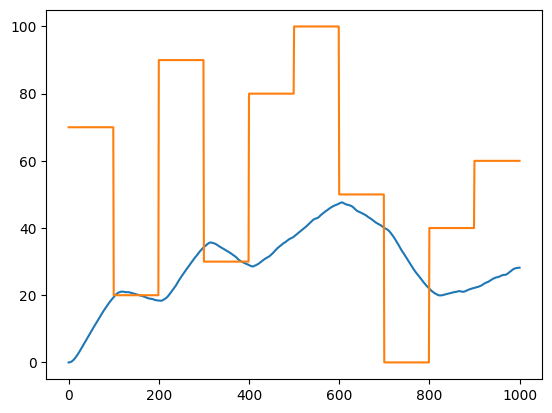

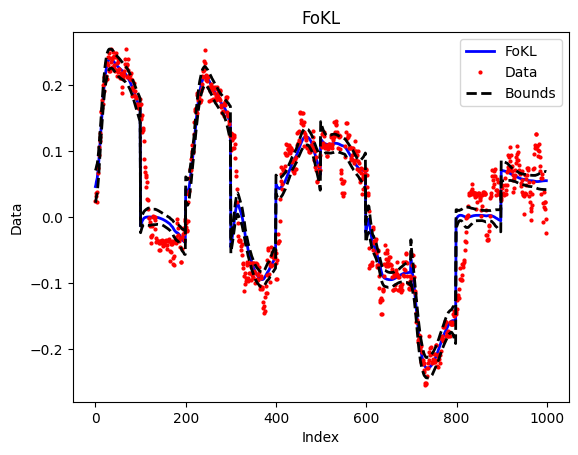

In [34]:
plt.plot(tvec[0], T[0])
plt.plot(tvec[0], u[0])

GP[0].coverage3(plot=True)

pred_dT = GP[0].evaluate()

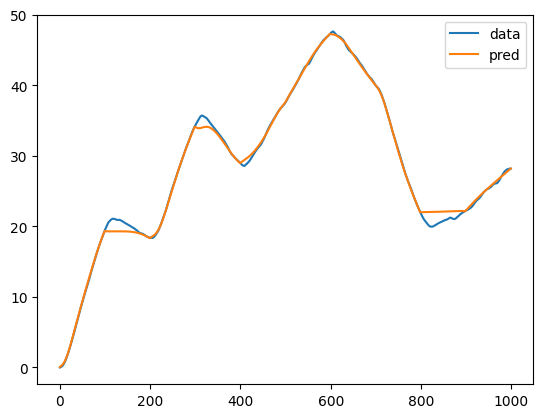

In [32]:
pred_T = np.cumsum(pred_dT)

plt.plot(train_T)
plt.plot(pred_T)
plt.legend(["data", "pred"])

In [ ]:
# https://ndcbe.github.io/controls/notebooks/02.05-Second-Order.html


# =====================================================================================

# Try your hand at trial and error data fitting

# adjustable parameters
CpH = 5                # joules/deg C
CpS = 1                # joules/deg C
Ua = 0.04             # watts/deg C
Ub = 0.04              # watts/deg C

A = np.array([[-(Ua + Ub)/CpH, Ub/CpH], [Ub/CpS, -Ub/CpS]])
B = np.array([[alpha*P1/CpH], [0]])
C = np.array([[0, 1]])

pred = tclab_ss(A, B, C)
ax = data["T1"].plot(grid=True, linestyle="", marker=".")
pred.plot(ax=ax, y=["TH1","TS1"],xlabel="Time (s)", ylabel="deg C", grid=True)
plt.legend(["TH1 (measured)", "TH1 (model)", "TS1 (model)"])
plt.show()

# =====================================================================================

def pred_err(p):
    
    CpH, CpS, Ua, Ub = p
    
    # array parameters
    A = np.array([[-(Ua + Ub)/CpH, Ub/CpH], [Ub/CpS, -Ub/CpS]])
    B = np.array([[alpha*P1/CpH], [0]])
    C = np.array([[0, 1]])
    
    pred = tclab_ss(A, B, C)
    return pred["T1"] - data["T1"]
    
pred_err([5.8, 1, 0.04, 0.045]).plot(xlabel="Time (s)", ylabel="Prediction Error (deg C)", grid=True, linestyle="", marker=".")

# =====================================================================================

from scipy.optimize import least_squares

results = least_squares(pred_err,  [8, 1, 0.05, 0.05], loss="cauchy")

CpH, CpS, Ua, Ub = results.x
print(f"CpH = {CpH},  CpS = {CpS},   Ua = {Ua},  Ub = {Ub}")

pred_err([CpH, CpS, Ua, Ub]).plot(xlabel="Time (s)", ylabel="Prediction Error (deg C)", grid=True, linestyle="", marker=".")

## Validation test via sine input

In [17]:
test = pd.read_csv(os.path.join(dir, "data", "tclab_sine_test.csv"))

test_tvec = test["Time"]
test_T = test["T1"]
test_u = test["Q1"]

test_dt = test_tvec[1] - test_tvec[0]

In [18]:
pred_T = [np.zeros_like(test_T), 
          np.zeros_like(test_T)]
for i in range(n):
    pred_T[i][0] = test_T[0]
    for t in range(len(pred_T[i]) - 1):
        pred_T[i][t + 1] = pred_T[i][t] + test_dt * GP[i].evaluate([pred_T[i][t], test_u[t]], clean=True, SingleInstance=True)[0]

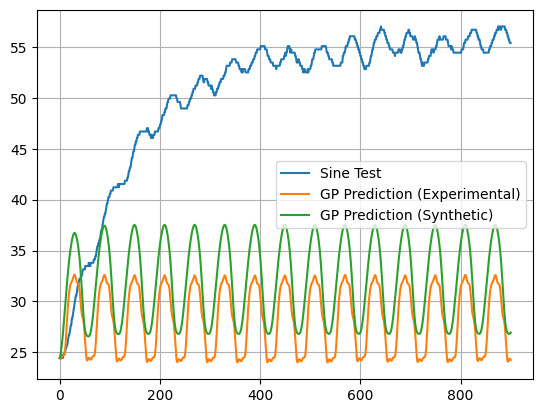

In [19]:
plt.plot(test_tvec, test_T, label="Sine Test")
plt.plot(test_tvec, pred_T[0], label="GP Prediction (Experimental)")
plt.plot(test_tvec, pred_T[1], label="GP Prediction (Synthetic)")
plt.legend()
plt.grid()

## IPOPT reference temperature

In [9]:
from scipy.interpolate import interp1d


# =====================================================================
# CONTROLLER REFERENCE TRAJECTORY:

t0 = 0                            # start time
tf = 999                          # end time
Tamb = 21.0                       # ambient temperature
tr = [t0, 50, 150, 450, 550, tf]  # time points of setpoint/reference values

def r(t):  # setpoint/reference (wrt Tamb)
    return np.interp(t, tr, np.array([Tamb, Tamb, 60, 60, 35, 35]) - Tamb)

dr = interp1d(tr, np.array([0, (60 - Tamb) / (150 - 50), 0, (35 - 60) / (550 - 450), 0, 0]), kind='previous')

In [20]:
import pyomo.environ as pyo
import pyomo.dae as dae


# =================================================================
# PYOMO MODEL:

m_all = []

for i in range(n):

    m = pyo.ConcreteModel("TCLab Heater with GP Model")

    m.t = dae.ContinuousSet(bounds=(t0, tf))

    m.u = pyo.Var(m.t, bounds=(0, 100), initialize=50)
    m.T = pyo.Var(m.t, bounds = GP[i].minmax[0])  # == T - Tamb
    m.dT = dae.DerivativeVar(m.T, wrt=m.t)

    m.T[t0].fix(0.0)  # initial conditions
    m.u[t0].fix(0.0)

    fokl_to_pyomo(GP[i], [m.T, m.u], m.dT, m, m.t)

    # Integral of squared error:
    @m.Integral(m.t, wrt=m.t)
    def ise(m, t):
        return (r(t) - m.T[t]) ** 2

    # Define the objective function:
    @m.Objective(sense=pyo.minimize)
    def objective(m):
        return m.ise
    
    # Apply a collocation method to numerically integrate the differential equations
    pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=100, wrt=m.t)
    # pyo.TransformationFactory('dae.finite_differenec', method='backward'').apply_to(m, nfe=100, wrt=m.t)  # LOOKUP SYNTAX
    #   - for sake of exact same calc aside from rounding

    m_all.append(m)

In [21]:
# Prepare Pyomo solver:
solver = pyo.SolverFactory('ipopt')
solver.options['linear_solver'] = 'ma57'

for i in range(n):

    # Call our nonlinear optimization/equation solver, Ipopt
    solver.solve(m_all[i] , tee=True)

Ipopt 3.13.2: linear_solver=ma57


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        compu

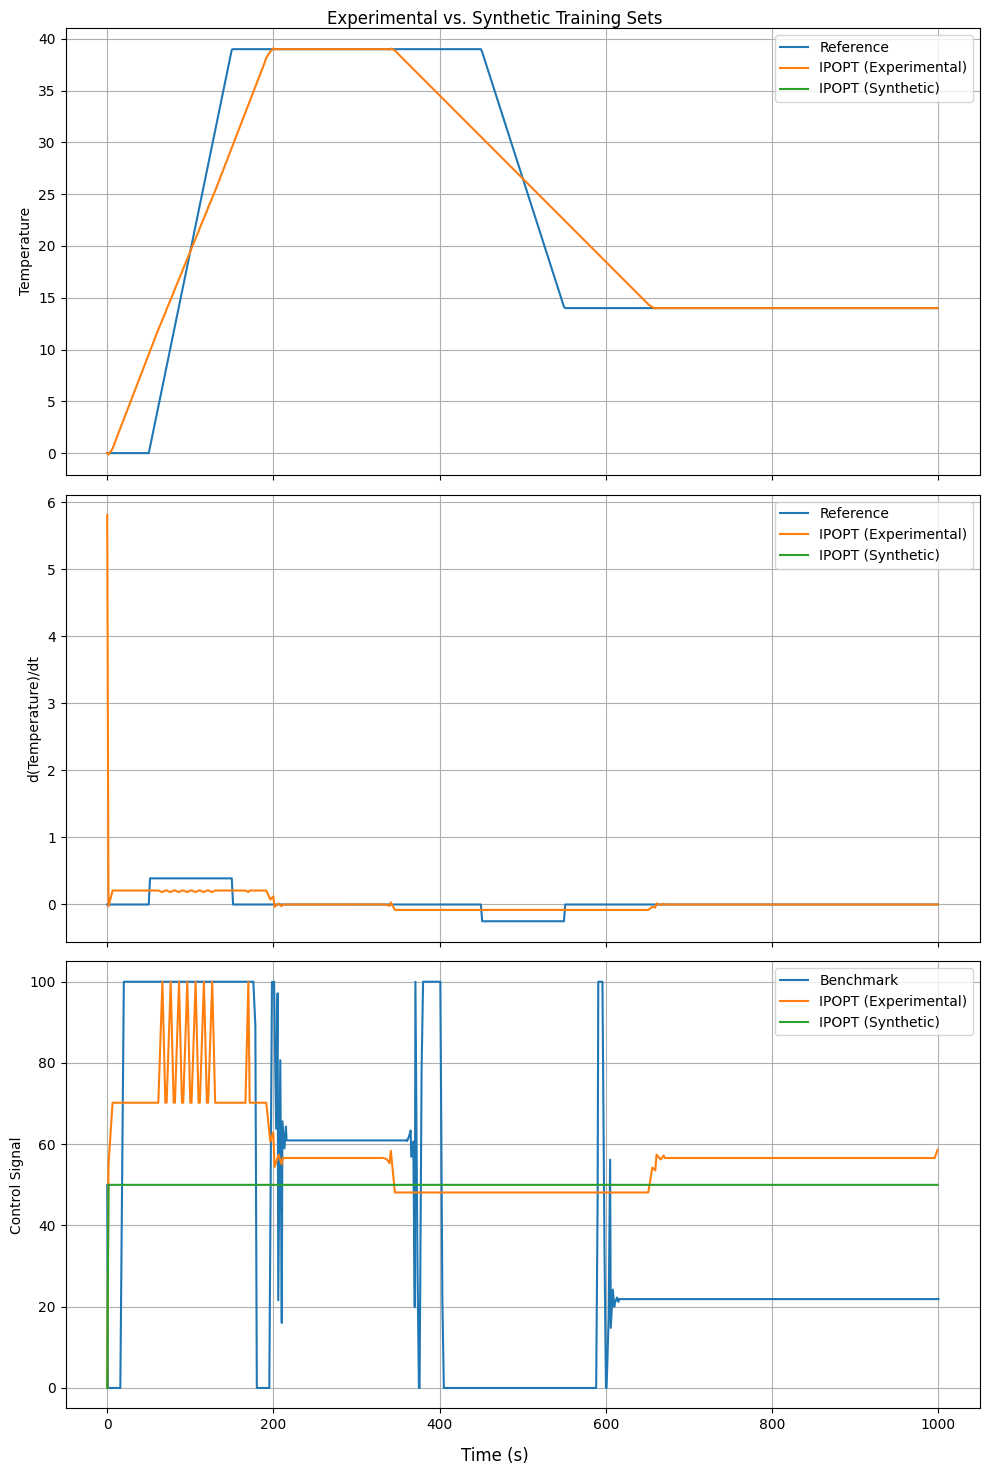

In [22]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10, 15))
fig.suptitle("Experimental vs. Synthetic Training Sets")
fig.supxlabel("Time (s)")

m = m_all[0]  # experimental
ms = m_all[1]  # synthetic

axs[0].plot(m.t, r(m.t), label="Reference")
axs[0].plot(m.t, m.T[:](), label="IPOPT (Experimental)")
# axs[0].plot(m.t, ms.T[:](), label="IPOPT (Synthetic)")
axs[0].set_ylabel("Temperature")

axs[1].plot(m.t, dr(m.t), label="Reference")
axs[1].plot(m.t, m.dT[:](), label="IPOPT (Experimental)")
# axs[1].plot(m.t, ms.dT[:](), label="IPOPT (Synthetic)")
# axs[1].plot(m.t, GP[0].evaluate([m.T[:](), m.u[:]()], clean=True), label="GP Check (Experimental)")
# axs[1].plot(m.t, GP[1].evaluate([ms.T[:](), ms.u[:]()], clean=True), label="GP Check (Synthetic)")
axs[1].set_ylabel("d(Temperature)/dt")

benchmark = pd.read_csv(os.path.join(dir, "data", "u1_benchmark_solution.csv"), header=None).values
axs[2].plot(benchmark[:, 0], benchmark[:, 1], label="Benchmark")
axs[2].plot(m.t, m.u[:](), label="IPOPT (Experimental)")
# axs[2].plot(m.t, ms.u[:](), label="IPOPT (Synthetic)")
axs[2].set_ylabel("Control Signal")

for ax in axs:
    ax.legend()
    ax.grid()

fig.tight_layout()

## Confirm GP embedded correctly

In [ ]:
# res_T = m.T[:]()  # results


# pred_T = np.zeros_like(res_T)
# for i in range(n):
#     pred_T[0] = res_T[0]
#     for t in range(len(pred_T[i]) - 1):
#         pred_T[t + 1] = pred_T[t] + test_dt * GP[i].evaluate([pred_T[i][t], test_u[t]], clean=True, SingleInstance=True)[0]